In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import re

## Load dirs

In [11]:
nback_dir = Path(r"..\..\data\0-back\beh+sub\0-back test")
wcst_before_dir = Path(r"..\..\data\0-back\beh+sub\wcst_before test")
wcst_after_dir  = Path(r"..\..\data\0-back\beh+sub\wcst_after test")

nback_files = list(nback_dir.glob("*.csv"))
wcst_before_files = list(wcst_before_dir.glob("*.csv"))
wcst_after_files  = list(wcst_after_dir.glob("*.csv"))

print(len(nback_files), "0-back files")
print(len(wcst_before_files), "WCST before files")
print(len(wcst_after_files), "WCST after files")

4 0-back files
4 WCST before files
4 WCST after files


In [12]:
participants = {}

file_groups = [
    ("before", wcst_before_files),
    ("after", wcst_after_files),
    ("nback", nback_files),
]

for key, files in file_groups:
    for f in files:
        match = re.match(r"^(\d+)_", f.name)
        if not match:
            continue

        pid = match.group(1)

        if pid not in participants:
            participants[pid] = {
                "before": None,
                "after": None,
                "nback": None
            }

        participants[pid][key] = f

In [17]:
for pid, files in sorted(participants.items(), key=lambda x: int(x[0])):
    print(f"\n--- Participant {pid} ---")

    print(f"BEFORE : {files['before']}")
    print(f"NBACK  : {files['nback']}")
    print(f"AFTER  : {files['after']}")


--- Participant 4 ---
BEFORE : ..\..\data\0-back\beh+sub\wcst_before test\4_Wisconsin Card Sorting Task_2026-04-21_13h25.30.802.csv
NBACK  : ..\..\data\0-back\beh+sub\0-back test\4_0back_2026-04-21_13h29.04.554.csv
AFTER  : ..\..\data\0-back\beh+sub\wcst_after test\4_Wisconsin Card Sorting Task_2026-04-21_13h43.48.229.csv

--- Participant 7 ---
BEFORE : ..\..\data\0-back\beh+sub\wcst_before test\7_Wisconsin Card Sorting Task_2026-04-20_10h38.40.604.csv
NBACK  : ..\..\data\0-back\beh+sub\0-back test\7_0back_2026-04-20_10h41.48.654.csv
AFTER  : ..\..\data\0-back\beh+sub\wcst_after test\7_Wisconsin Card Sorting Task_2026-04-20_10h56.26.413.csv

--- Participant 8 ---
BEFORE : ..\..\data\0-back\beh+sub\wcst_before test\8_Wisconsin Card Sorting Task_2026-04-10_15h45.28.124.csv
NBACK  : ..\..\data\0-back\beh+sub\0-back test\8_0back_2026-04-10_15h48.35.876.csv
AFTER  : ..\..\data\0-back\beh+sub\wcst_after test\8_Wisconsin Card Sorting Task_2026-04-10_16h03.52.320.csv

--- Participant 9 ---
BE

## Subjective sleepiness results

In [21]:
participant_data = {}

for pid, files in participants.items():
    participant_data[pid] = {
        "wcst_before": pd.read_csv(files["before"]),
        "wcst_after": pd.read_csv(files["after"]),
        "nback": pd.read_csv(files["nback"])
    }

In [26]:
rows = []

for pid, data in participant_data.items():
    nback_df = data["nback"].copy()

    # Clean RSME column
    nback_df["RSME"] = pd.to_numeric(
        nback_df["RSME_ticks.response"], errors="coerce"
    )

    nback_df = nback_df[nback_df["RSME"].notna()].copy().reset_index(drop=True)

    if len(nback_df) == 0:
        continue

    # Create block index
    nback_df["block"] = np.arange(1, len(nback_df) + 1)

    # Keep target if exists
    if "target" in nback_df.columns:
        nback_df["target"] = nback_df["target"]
    else:
        nback_df["target"] = np.nan

    # Store
    for _, row in nback_df.iterrows():
        rows.append({
            "pid": int(pid),
            "block": row["block"],
            "RSME": row["RSME"]
        })

# Final DataFrame
df_rsme = pd.DataFrame(rows)

print("Participants:", df_rsme["pid"].nunique())
print(df_rsme)

Participants: 4
    pid  block  RSME
0     4      1   3.0
1     4      2   3.0
2     4      3   4.0
3     4      4   4.0
4     7      1   3.0
5     7      2   3.0
6     7      3   4.0
7     7      4   4.0
8     8      1   7.0
9     8      2   7.0
10    8      3   7.0
11    8      4   8.0
12    9      1   4.0
13    9      2   5.0
14    9      3   7.0
15    9      4   9.0


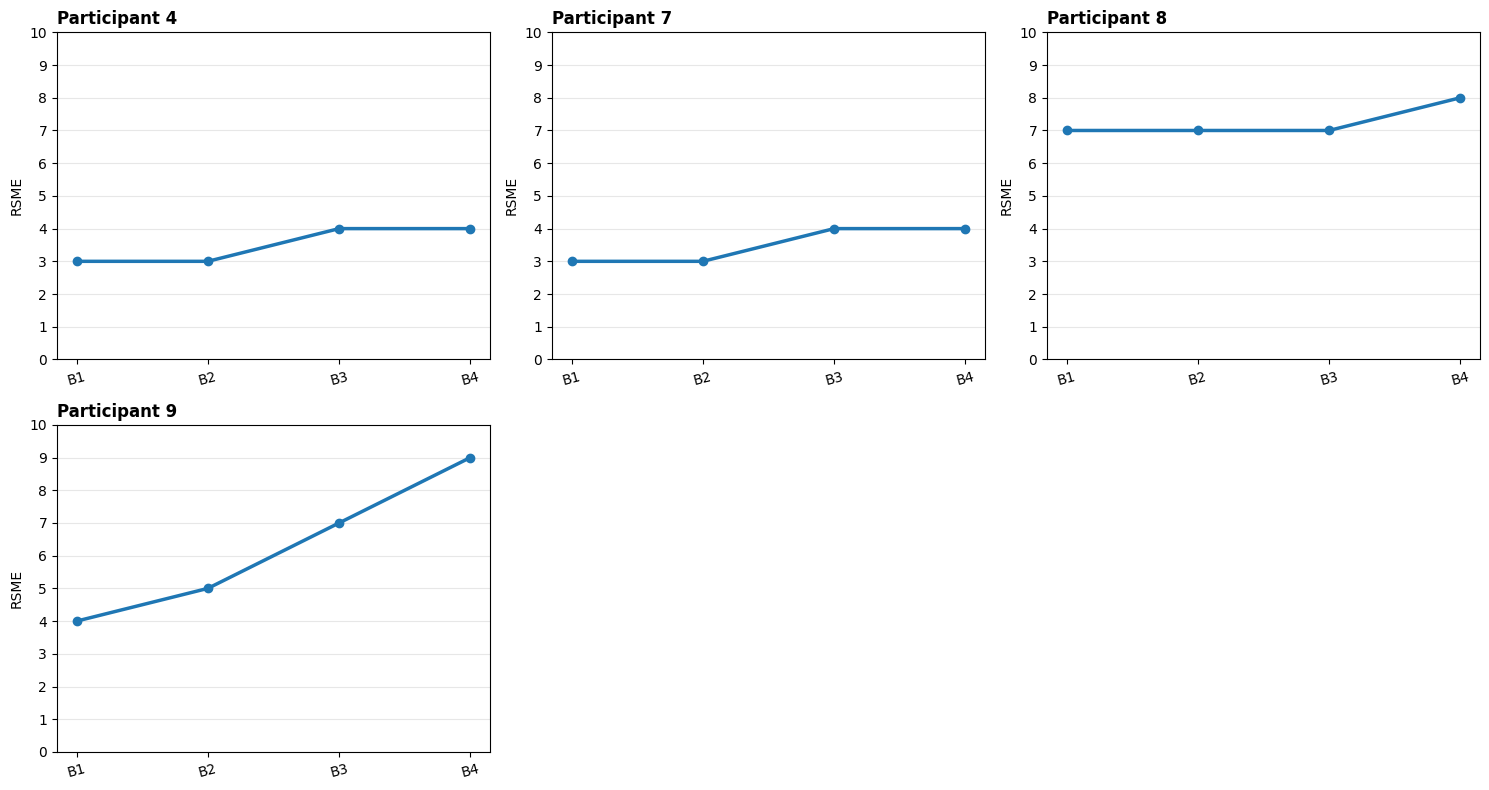

In [ ]:
pids = sorted(df_rsme["pid"].unique())
ncols = 3
nrows = int(np.ceil(len(pids) / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(5*ncols, 4*nrows))
axes = np.array(axes).reshape(-1)

for ax, pid in zip(axes, pids):
    temp = df_rsme[df_rsme["pid"] == pid]

    if temp.empty:
        ax.set_title(f"P{pid} - no data")
        ax.axis("off")
        continue

    ax.plot(temp["block"], temp["RSME"], marker="o", linewidth=2.5)

    # labels with target if available
    if temp["target"].notna().any():
        xlabels = [f"B{b}" for b in temp["block"]]
    else:
        xlabels = [f"B{b}" for b in temp["block"]]

    ax.set_title(f"Participant {pid}", loc="left", fontweight="bold")
    ax.set_ylabel("RSME")
    ax.set_xticks(temp["block"])
    ax.set_xticklabels(xlabels, rotation=15)
    ax.set_yticks(range(0, 11))
    ax.grid(axis="y", alpha=0.3)

# Hide empty plots
for ax in axes[len(pids):]:
    ax.axis("off")

plt.tight_layout()
plt.show()